# 01 — Exploratory Data Analysis: what drives invoice risk?

**Business question:** which invoice lines are most likely to be returned or cancelled, so reviewers can focus on the small fraction of lines that carries most of the financial risk?

**Unit of analysis:** one invoice line. **Risk event:** `is_return` = `quantity < 0` (return / cancellation line).

**Note on method:** this notebook is deliberately exploratory — statistics are computed on the full dataset to build intuition. All model features will later be computed *point-in-time* (only from data strictly before each line) to avoid leakage; see `src/features.py`.

Flow: data quality recap → univariate distributions → risk signal by segment and time → hypothesis tests → feature hypotheses.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "config.yaml").exists() and (ROOT.parent / "config.yaml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: C:\Users\hp\Documents\Qoder\2026-10-07\6fa16f90


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import load_config

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"eda_{name}.png", bbox_inches="tight")

cfg = load_config()
df = pd.read_parquet(ROOT / cfg["data"]["interim_dir"] / cfg["data"]["interim_file"])
df["is_return"] = df["quantity"] < 0
print(f"{len(df):,} lines | {df['invoice_no'].nunique():,} invoices | {df['customer_id'].nunique():,} customers")
print(f"date range: {df['invoice_date'].min():%Y-%m-%d} to {df['invoice_date'].max():%Y-%m-%d}")
df.head(3)

1,067,371 lines | 53,628 invoices | 5,942 customers
date range: 2009-12-01 to 2011-12-09


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancellation,line_amount,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,False


## 1. Data quality recap

Full machine-readable report: `reports/data_quality.json` (generated by `python -m src.validate`). Key characteristic of this dataset: a large share of lines has no customer ID, and many lines have non-positive prices or exact duplicates.

customer_id    0.227669
dtype: float64

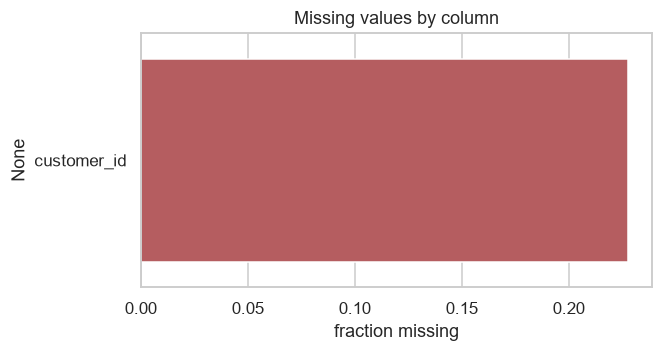

In [3]:
missing = df.isna().mean()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color="#c44e52")
ax.set_xlabel("fraction missing")
ax.set_title("Missing values by column")
save(fig, "missingness")
missing

In [4]:
def iqr_outlier_share(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()

stats_tbl = pd.DataFrame(
    {
        "min": [df["quantity"].min(), df["unit_price"].min(), df["line_amount"].min()],
        "median": [df["quantity"].median(), df["unit_price"].median(), df["line_amount"].median()],
        "max": [df["quantity"].max(), df["unit_price"].max(), df["line_amount"].max()],
        "iqr_outlier_share": [
            iqr_outlier_share(df["quantity"]),
            iqr_outlier_share(df["unit_price"]),
            iqr_outlier_share(df["line_amount"]),
        ],
    },
    index=["quantity", "unit_price", "line_amount"],
)
print(f"unit_price <= 0: {(df['unit_price'] <= 0).sum():,} lines ({(df['unit_price'] <= 0).mean():.3%})")
print(f"quantity == 0:   {(df['quantity'] == 0).sum():,} lines")
stats_tbl

unit_price <= 0: 6,207 lines (0.582%)
quantity == 0:   0 lines


,min,median,max,iqr_outlier_share
quantity,-80995.00,3.0,80995.0,0.109136
unit_price,-53594.36,2.1,38970.0,0.063806
line_amount,-168469.60,9.9,168469.6,0.085183


## 2. The risk signal: returns and cancellations

The target event (`quantity < 0`) is rare — this is an imbalanced classification problem, which is why the modeling stage will be judged on PR-AUC and precision@k rather than accuracy.

return/cancellation lines: 2.15% of all lines
cancellation invoices: 8,292 of 53,628


,return_rate,lines
country,,
Germany,0.052258,17624
EIRE,0.028658,17866
France,0.027146,14330
United Kingdom,0.020489,981330
Netherlands,0.009144,5140


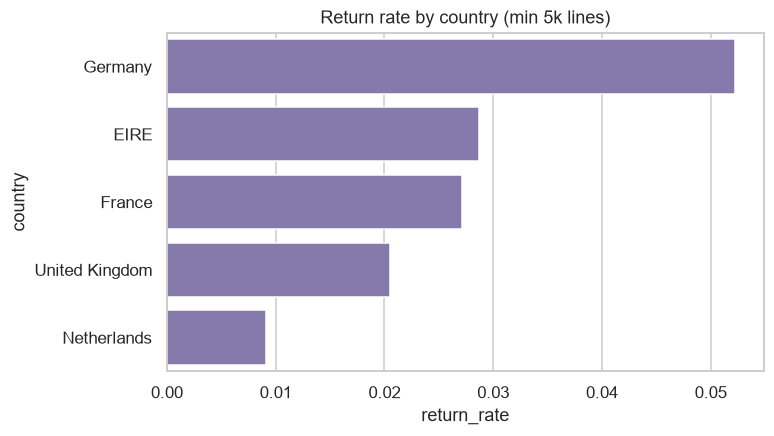

In [5]:
print(f"return/cancellation lines: {df['is_return'].mean():.2%} of all lines")
print(f"cancellation invoices: {df.loc[df['is_cancellation'], 'invoice_no'].nunique():,} of {df['invoice_no'].nunique():,}")

by_country = (
    df.groupby("country")["is_return"]
    .agg(return_rate="mean", lines="size")
    .query("lines >= 5000")
    .sort_values("return_rate", ascending=False)
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_country.head(12).reset_index(), x="return_rate", y="country", ax=ax, color="#8172b3")
ax.set_title("Return rate by country (min 5k lines)")
save(fig, "return_rate_by_country")
by_country.head(12)

## 3. Temporal patterns

Invoice volume shows strong seasonality (Q4 spike). Return rate must be checked for temporal stability — if it drifts, the monitoring stage needs drift thresholds.

,lines,return_rate
invoice_date,,
2011-05-01,37030,0.019930
2011-06-01,36874,0.022184
2011-07-01,39518,0.020295
2011-08-01,35284,0.020349
2011-09-01,50226,0.017979
2011-10-01,60742,0.022159
2011-11-01,84711,0.014319
2011-12-01,25526,0.015279


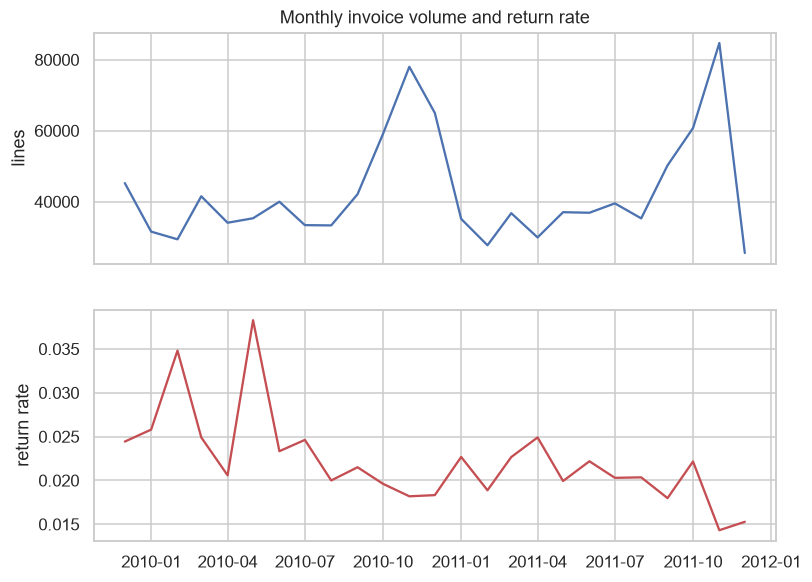

In [6]:
monthly = (
    df.set_index("invoice_date")
    .resample("MS")
    .agg(lines=("invoice_no", "size"), return_rate=("is_return", "mean"))
)
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(monthly.index, monthly["lines"], color="#4c72b0")
axes[0].set_ylabel("lines")
axes[0].set_title("Monthly invoice volume and return rate")
axes[1].plot(monthly.index, monthly["return_rate"], color="#c44e52")
axes[1].set_ylabel("return rate")
save(fig, "temporal")
monthly.tail(8)

## 4. Hypothesis tests

- **H1:** returned lines differ in amount from kept lines (returned goods are typically higher-value).
- **H2:** a small share of customers accounts for most returns — customer history is predictive.
- **H3:** return behavior differs between repeat and one-time customers.

Exact p-values are printed below; they inform which features are worth engineering (point-in-time versions of each hypothesis go into `src/features.py`).

In [7]:
# H1: amount difference
returned = df.loc[df["is_return"], "line_amount"].abs()
kept = df.loc[~df["is_return"], "line_amount"].abs()
u_stat, p_val = stats.mannwhitneyu(returned, kept, alternative="two-sided")
print(f"H1 Mann-Whitney |line_amount| returned vs kept: p = {p_val:.2e}")
print(f"   median returned |amount|: {returned.median():.2f} | median kept: {kept.median():.2f}")

# H2: return concentration across customers
cust = (
    df.dropna(subset=["customer_id"])
    .groupby("customer_id")
    .agg(return_rate=("is_return", "mean"), lines=("is_return", "size"))
)
active = cust[cust["lines"] >= 20]
top_decile = active[active["return_rate"] >= active["return_rate"].quantile(0.9)]
share_of_returns = top_decile["return_rate"].mul(top_decile["lines"]).sum() / df["is_return"].sum()
print(f"H2 top-10% of active customers account for {share_of_returns:.1%} of returned lines")

# H3: repeat vs one-time customers
n_invoices = df.dropna(subset=["customer_id"]).groupby("customer_id")["invoice_no"].nunique()
segment = df.dropna(subset=["customer_id"]).assign(
    segment=lambda d: d["customer_id"].map(n_invoices.ge(2)).map({True: "repeat", False: "one_time"})
)
table = pd.crosstab(segment["segment"], segment["is_return"]).rename(
    columns={False: "kept", True: "returned"}
)
chi2, p_chi, dof, _ = stats.chi2_contingency(table)
print(f"H3 chi-square repeat vs one-time customers: chi2 = {chi2:,.0f}, p = {p_chi:.2e}")
(table["returned"] / table.sum(axis=1)).to_frame("return_rate")

H1 Mann-Whitney |line_amount| returned vs kept: p = 0.00e+00
   median returned |amount|: 6.75 | median kept: 9.96


H2 top-10% of active customers account for 31.3% of returned lines


H3 chi-square repeat vs one-time customers: chi2 = 506, p = 4.07e-112


,return_rate
segment,
one_time,0.003775
repeat,0.023458


## Findings & feature hypotheses

1. **Strong class imbalance** (return lines are a small minority of all lines). Implication: accuracy is useless; use PR-AUC, precision@k, and cost-weighted thresholds. H2 suggests optimizing precision@k directly maps to reviewer capacity.
2. **~25% of lines have no customer ID.** Implication: the feature set must degrade gracefully for unknown customers — product-level and line-level features only.
3. **Returns are concentrated in a subset of customers** (H2). Implication: customer historical return rate, computed point-in-time, is a candidate top feature. → leakage-safe implementation required.
4. **Returned lines differ in amount from kept lines** (H1). Implication: deviation features — line amount vs. the product's historical median price, quantity vs. the customer's typical quantity.
5. **Return rate varies over time and by country.** Implication: month / day-of-week features plus drift monitoring with PSI thresholds.
6. **Non-positive prices and duplicate lines exist.** Implication: invoice-level anomaly counts (zero-price lines, duplicate lines) can be legitimate features rather than noise to discard.

The final cell persists a machine-readable summary to `reports/eda_summary.json`, used in the README.

In [8]:
import json

summary = {
    "n_lines": int(len(df)),
    "n_invoices": int(df["invoice_no"].nunique()),
    "n_customers": int(df["customer_id"].nunique()),
    "return_line_share": float(df["is_return"].mean()),
    "customer_id_missing_share": float(df["customer_id"].isna().mean()),
    "nonpositive_price_share": float((df["unit_price"] <= 0).mean()),
    "top_customer_decile_return_share": float(share_of_returns),
    "date_min": str(df["invoice_date"].min().date()),
    "date_max": str(df["invoice_date"].max().date()),
}
(ROOT / "reports" / "eda_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary

{'n_lines': 1067371,
 'n_invoices': 53628,
 'n_customers': 5942,
 'return_line_share': 0.021501427338760374,
 'customer_id_missing_share': 0.22766872999172733,
 'nonpositive_price_share': 0.005815222635803296,
 'top_customer_decile_return_share': 0.31254901960784315,
 'date_min': '2009-12-01',
 'date_max': '2011-12-09'}